# Neural Net Code | CogSci 131 - Spring 2026
Moving from a perceptron to a neural net is a matter of judging outputs on a metric between 0 and 1. *If* the activation of a neuron is necessary for a "correct" output, *then* adjust the weights leading to that neuron from the input(s) to stimulate activation.

In [364]:
# Install Dependencies (You may need to restart after this process is complete)
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


## Part 1 - Basic Neural Net Structure
The code below aims to display how a neural net (physically) works through code and how we can initiate "learning" with said neural net.

In [365]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import time


class Neural_Network(object):
    def __init__(self, func='sig'):
        # Neural Net Structure Parameters
        self.inputLayerSize  = 2
        self.hiddenLayerSize = 3
        self.outputLayerSize = 1
        self.W1 = np.random.rand(self.inputLayerSize, self.hiddenLayerSize)
        self.W2 = np.random.rand(self.hiddenLayerSize, self.outputLayerSize)
        match func:
            case 'sig':
                self.funcFP = self.sigmoid
                self.funcBP = self.sigmoidPrime
                self.funcFP_hidden = self.sigmoid
                self.funcBP_hidden = self.sigmoidPrime
            case 'relu':
                self.funcFP = self.sigmoid
                self.funcBP = self.sigmoidPrime
                self.funcFP_hidden = self.relu
                self.funcBP_hidden = self.reluPrime
            case _:
                raise ValueError("Unavailable function selection")
        
        # Results
        self.costs = []
        self.accuracy = 1
        
    def forward(self, X):
        # Propogate inputs through network
        self.z2 = np.dot(X, self.W1)        #Input * Weight(s)
        self.a2 = self.funcFP_hidden(self.z2) #See if Input * Weight(s) activates next node
        self.z3 = np.dot(self.a2, self.W2)  #Activation (of z2) * Weight(s)
        yHat = self.funcFP(self.z3)    #See if z2 * Weight(s) activates output
        return yHat
    
    # Sigmoid for Binary Classification or Bounded Output Ranges (0 to 1)
    def sigmoid(self, z):
        # Apply Sigmoid Activation Function
        return 1 / (1 + np.exp(-z)) # 1 / (1 + e^(-z))
    
    def sigmoidPrime(self, z):
        # Derivative of Sigmoid Function
        return (np.exp(-z)) / ((1 + np.exp(-z))**2) # (e^(-z)) / ((1 + e^(-z))^2)
    
    # ReLU (Rectified Linear Unit) returns input and avoids "vanishing gradient problem"
    def relu(self, z):
        # Returns input value if positive (0 if negative)
        return np.maximum(0, z)
    
    def reluPrime(self, z):
        # Returns input value if it was passed through
        return 1 * (z > 0) # 0 if (z <= 0); z if (z > 0)
    
    def costFunction(self, X, y):
        # Compute Cost Function with weights stored in class
        self.yHat = self.forward(X)
        J = 0.5 * np.sum((y - self.yHat)**2) # 1/2 * E((y - yHat)^2)
        return J
    
    def costFunctionPrime(self, X, y):
        # Compute derivatives with respect to W1 and W2
        self.yHat = self.forward(X)
        d3 = np.multiply(-(y - self.yHat), self.funcBP(self.z3))
        dJdW2 = np.dot(self.a2.T, d3) # .T transposes a NumPy matrix (to be properly multiplied)
        d2 = np.dot(d3, self.W2.T) * self.funcBP_hidden(self.z2)
        dJdW1 = np.dot(X.T, d2)
        return dJdW1, dJdW2
    
    
    # Helper functions for interacting with other methods/classes
    
    def getParams(self):
        # Get W1 and W2 rolled into a vector
        params = np.concatenate((self.W1.ravel(), self.W2.ravel()))
        return params
    
    def setParams(self, params):
        params = np.asarray(params).ravel()
        
        W1_start = 0
        W1_end = self.inputLayerSize * self.hiddenLayerSize
        self.W1 = np.reshape(
            params[W1_start:W1_end],
            (self.inputLayerSize, self.hiddenLayerSize)
        )
        
        W2_end = W1_end + (self.hiddenLayerSize * self.outputLayerSize)
        self.W2 = np.reshape(
            params[W1_end:W2_end],
            (self.hiddenLayerSize, self.outputLayerSize)
        )
    
    def computeGradients(self, X, y):
        dJdW1, dJdW2 = self.costFunctionPrime(X, y)
        return np.concatenate((dJdW1.ravel(), dJdW2.ravel()))
    
    def computeNumericalGradient(self, X, y):
        paramsInitial = self.getParams().ravel()
        numgrad = np.zeros(paramsInitial.shape)  # (Input annotations)
        perturb = np.zeros(paramsInitial.shape)
        e = 1e-4
        
        for p in range(paramsInitial.size):
            # Set perturbation vector
            perturb[p] = e
            
            self.setParams(paramsInitial + perturb)
            loss2 = self.costFunction(X, y)
            
            self.setParams(paramsInitial - perturb)
            loss1 = self.costFunction(X, y)
            
            # Compute Numerical Gradient using perturbations to extract slope at some point
            numgrad[p] = (loss2 - loss1) / (2*e)
            
            # Revert the changed value to zero
            perturb[p] = 0.0
            
        # Return Params to original values
        self.setParams(paramsInitial)
        
        return numgrad  # Collection of numerical gradients for whole Neural Net
    
    def checkGradients(self, X, y):
        # Compare Analytical vs. Numerical gradients (for debugging backprop)
        return self.computeGradients(X, y) - self.computeNumericalGradient(X, y)
    
    def computeAccuracy(self, X, y) -> float:
        # Compute predictions
        yHat = self.forward(X)
        # Calculate Mean Square Error (MSE)
        mse = np.mean((y - yHat)**2) # (y - yHat)^2 to remove negative values
        return mse

In [366]:
def trainIter(NN,X,y,n,c) -> Neural_Network:
    NN.costs = []
    for _ in range(n):
        dJdW1,dJdW2 = NN.costFunctionPrime(X, y)
        NN.W1 = NN.W1 - (c*dJdW1)
        NN.W2 = NN.W2 - (c*dJdW2)
        NN.costs.append(NN.costFunction(X,y))
    return NN

def trainAcc(NN,X,y,acc,c, maxIter=float("inf")) -> Neural_Network:
    NN.costs = []
    accuracy = NN.computeAccuracy(X,y)
    i=0
    while accuracy > acc:
        dJdW1,dJdW2 = NN.costFunctionPrime(X, y)
        NN.W1 = NN.W1 - (c*dJdW1)
        NN.W2 = NN.W2 - (c*dJdW2)
        NN.costs.append(NN.costFunction(X,y))
        accuracy = NN.computeAccuracy(X,y)
        if i > maxIter:
            break
        else:
            i+=1
    return NN

In [367]:
def plotCost(models) -> None:
    # Plot one or more runs
    costs = list(map(lambda NN:NN.costs, models))
    # Check for whether it's one run or a collection of runs
    if (
        isinstance(costs, (list, tuple))
        and len(costs) > 0
        and isinstance(costs[0], (list, tuple, np.ndarray))
    ):
        for i, cost in enumerate(costs):
            plt.plot(cost, linewidth=2)
    else:
        plt.plot(costs, linewidth=2)

    plt.title("Cost vs. Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.show()

def plotData(times: dict) -> None:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    funcs = list(times.keys())
    colors = {'sig': 'blue', 'relu': 'orange'}
    labels = {'sig': 'Sigmoid', 'relu': 'ReLU'}
    
    for func in funcs:
        # Unpack tuples: (runtime, accuracy)
        runtimes_ms = [t[0] * 1000 for t in times[func]]  # Convert to ms
        final_accuracies = [t[1] for t in times[func]]
        
        ax.scatter(runtimes_ms, final_accuracies,
                   color=colors[func], 
                   alpha=0.7, 
                   s=80,
                   label=labels[func],
                   edgecolors='black',
                   linewidth=0.5)
    
    ax.set_xlabel('Runtime (ms)')
    ax.set_ylabel('Final MSE (Accuracy)')
    ax.set_title('Training Time vs Final Accuracy: Sigmoid vs ReLU')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Values of Vars in NN

#### Initial Values
Instantiate the training set from which to solve. The given data is asking what score someone is likely to get with x1 *Hours of Sleep* and x2 *Hours of Study* mapped to some y *Test Score*.

**Goal**

Generate a yHat (Test Score), given x1 (Sleep) and x2 (Study), that is as close to as accurate as possible. Train the NN with test data by adjusting weights such that they generate yHat values that most closely align with y (real world) via costFunctionPrime and weight adjustment. Use the newly trained model to predict test scores with novel x1 and x2.

In [368]:
X=np.array(([3,5],[5,1],[10,1]),dtype=float)  # (Hours of Sleep, Hours of Study)
y=np.array(([75],[80],[93]),dtype=float)  # Score on Test (maps to X)

X = X/np.amax(X, axis=0)  # Return the maximum of an array (along an axis)
y = y/100  # Convert score to percentage (75 -> 0.75)

X,y

(array([[0.3, 1. ],
        [0.5, 0.2],
        [1. , 0.2]]),
 array([[0.75],
        [0.8 ],
        [0.93]]))

### Plotting the Cost Function

"Training" (populate cost array to show progress)
- First code: Signage Effects
  - Show how the sign affects directionality (in relation to cost function)
- Second code: High Scalar
  - Show how a high scalar impacts results
- Third code: Low Scalar
  - Show how a low scalar impacts results

#### Signage Effects

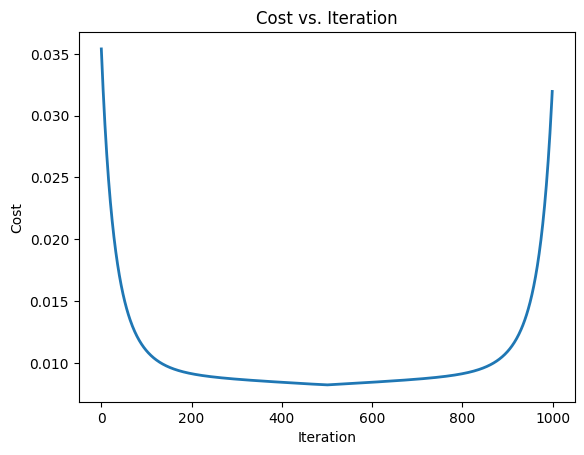

In [369]:
NN = Neural_Network('sig')
scalar = 0.1

for i in range(1000):
    dJdW1,dJdW2 = NN.costFunctionPrime(X, y)
    if i < 500:
        NN.W1 = NN.W1 - scalar*dJdW1
        NN.W2 = NN.W2 - scalar*dJdW2
    else:
        NN.W1 = NN.W1 + scalar*dJdW1
        NN.W2 = NN.W2 + scalar*dJdW2
    NN.costs.append(NN.costFunction(X,y))

plotCost([NN])

The graph shows that subtracting the (scalar * Jacobian) gets the cost of the NN down (bringing it closer to the real world data), where as the inverse happens when you add it.

Intuitively, this makes sense as you are navigating a gradient that is a representation of the real world/model world difference. To get the two to be closer in outputs, you would need to move down the gradient by adjusting your position (using the slope derived from the Jacobian for each respective Weight matrix).

#### High Scalar

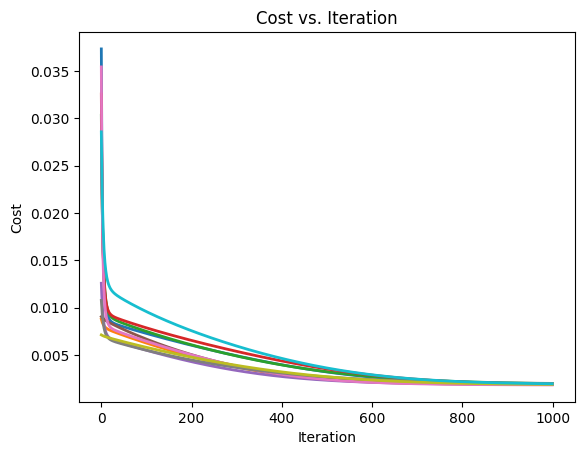

In [370]:
models = []
for _ in range(10):
    NN = Neural_Network('sig')
    trainIter(NN,X,y,1000,1)
    models.append(NN)
plotCost(models)

In [371]:
print(f"Accuracy of each model:")
for i, model in enumerate(models, 1):
    print(f"Run #{i}: {model.computeAccuracy(X,y):.8f}")

Accuracy of each model:
Run #1: 0.00128769
Run #2: 0.00125458
Run #3: 0.00131832
Run #4: 0.00126970
Run #5: 0.00125121
Run #6: 0.00127039
Run #7: 0.00122474
Run #8: 0.00133157
Run #9: 0.00125790
Run #10: 0.00130489


##### High Scalar - Cost Minima 0.001
![](Attachments/High%20-%200.001.png)

The effect of a high scalar is best described as a more intense "learning curve" where in (practically speaking) you are pushed further into a local minima. This means that your training times are much lower, but you get less iterations to check the directionality of your output (whether the outputs are starting to approximate the desired output).

#### Low Scalar

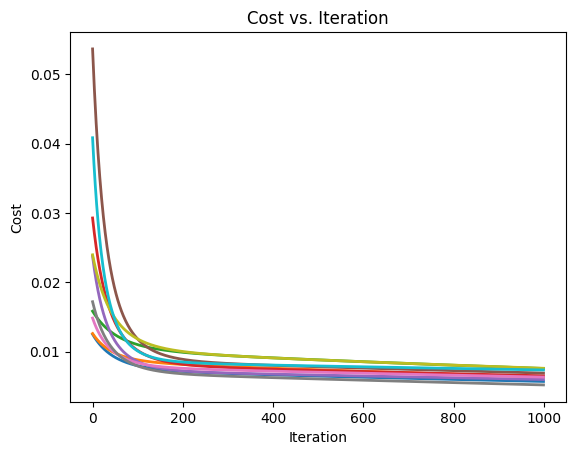

In [372]:
models = []
for _ in range(10):
    NN = Neural_Network('sig')
    trainIter(NN,X,y,1000,0.1)
    models.append(NN)
plotCost(models)

In [373]:
print(f"Accuracy of each model:")
for i, model in enumerate(models, 1):
    print(f"Run #{i}: {model.computeAccuracy(X,y):.8f}")

Accuracy of each model:
Run #1: 0.00379230
Run #2: 0.00422258
Run #3: 0.00504035
Run #4: 0.00433725
Run #5: 0.00398424
Run #6: 0.00459781
Run #7: 0.00421220
Run #8: 0.00345877
Run #9: 0.00505927
Run #10: 0.00489923


##### Low Scalar - Cost Minima 0.001
![](Attachments/Low%20-%200.001.png)

The effect of a low scalar is that you are able to slow down training to a more gentle curve where in (practically speaking) you are able to obtain more info early about the training progress and allowing you to redirect your training elsewhere if needed. Furthermore, you avoid any "rebounding" where you over adjust a weight and need to readjust it back (leading to more consistent training).

However, the downside of this approach is that (when using the Sigmoid function) the training time/iterations grows. While the High Scalar took ~100,000 iterations to reach the desires minima, the Low Scalar took ~175,000 iterations to do so.

## Part 2 - ReLU Function and Neural Nets

Defined in Part 1, the ReLU (Rectified Linear Unit) function returns the input into a node if the function becomes "activated" (like a neuron might with an action potential). This function is far more computationaly efficient and transmits more discrete data than the Sigmoid function does; however, if you are in need of a more binary output or some value between 0 and 1, the sigmoid still remains a strong option.

Furthermore, the ReLU function avoids an issue that is present in the Sigmoid function in which the compression of the inputs to a value between 0 and 1 causes intensity to be lost, leading to the "vanishing gradient problem" which impacts the training needed for weight matricies.

### Comparing the Training Functions

In [418]:
data = {}

n = 10
scalar = 0.01
acc = 0.005
maxIter = 50000

dataSig = []
rtSig = []
for _ in range(n):
    start = time.time()
    NNSig = Neural_Network('sig')
    NNSig = trainAcc(NNSig,X,y,acc,scalar,maxIter)
    stop = time.time()
    runtime = stop - start
    final_acc = NNSig.computeAccuracy(X,y)
    dataSig.append((runtime, final_acc))
    rtSig.append(runtime)
data['sig'] = dataSig
rtSigFmt = list(map(lambda x:((x*1000)//0.01)/100, rtSig))
rtSigAvg = ((sum(rtSigFmt)/len(rtSig))//0.01)/100

dataRelu = []
rtRelu = []
for _ in range(n):
    start = time.time()
    NNRelu = Neural_Network('relu')
    NNRelu = trainAcc(NNRelu,X,y,acc,scalar,maxIter)
    stop = time.time()
    runtime = stop - start
    final_acc = NNRelu.computeAccuracy(X,y)
    dataRelu.append((runtime, final_acc))
    rtRelu.append(runtime)
data['relu'] = dataRelu
rtReluFmt = list(map(lambda x:((x*1000)//0.01)/100, rtRelu))
rtReluAvg = ((sum(rtReluFmt)/len(rtRelu))//0.01)/100

In [419]:
print("Time for ~0.005 MSE (Accuracy)")
print("------------------------------")

print(f"Sigmoid (avg) = {rtSigAvg} ms")
print(f"Max: {max(rtSigFmt)} ms | Min: {min(rtSigFmt)} ms")
for i in range(len(rtSigFmt)):
    print(f" - Sigmoid #{i+1}: {rtSigFmt[i]} ms")

print(f"\nReLU (avg) = {rtReluAvg} ms")
print(f"Max: {max(rtReluFmt)} ms | Min: {min(rtReluFmt)} ms")
for i in range(len(rtReluFmt)):
    print(f" - ReLU #{i+1}: {rtReluFmt[i]} ms")

Time for ~0.005 MSE (Accuracy)
------------------------------
Sigmoid (avg) = 647.89 ms
Max: 1056.9 ms | Min: 14.57 ms
 - Sigmoid #1: 921.42 ms
 - Sigmoid #2: 690.03 ms
 - Sigmoid #3: 526.46 ms
 - Sigmoid #4: 387.66 ms
 - Sigmoid #5: 14.57 ms
 - Sigmoid #6: 994.41 ms
 - Sigmoid #7: 810.28 ms
 - Sigmoid #8: 343.11 ms
 - Sigmoid #9: 1056.9 ms
 - Sigmoid #10: 734.14 ms

ReLU (avg) = 101.04 ms
Max: 184.74 ms | Min: 57.17 ms
 - ReLU #1: 105.9 ms
 - ReLU #2: 83.97 ms
 - ReLU #3: 148.64 ms
 - ReLU #4: 57.31 ms
 - ReLU #5: 70.79 ms
 - ReLU #6: 61.75 ms
 - ReLU #7: 57.17 ms
 - ReLU #8: 184.74 ms
 - ReLU #9: 109.24 ms
 - ReLU #10: 130.91 ms


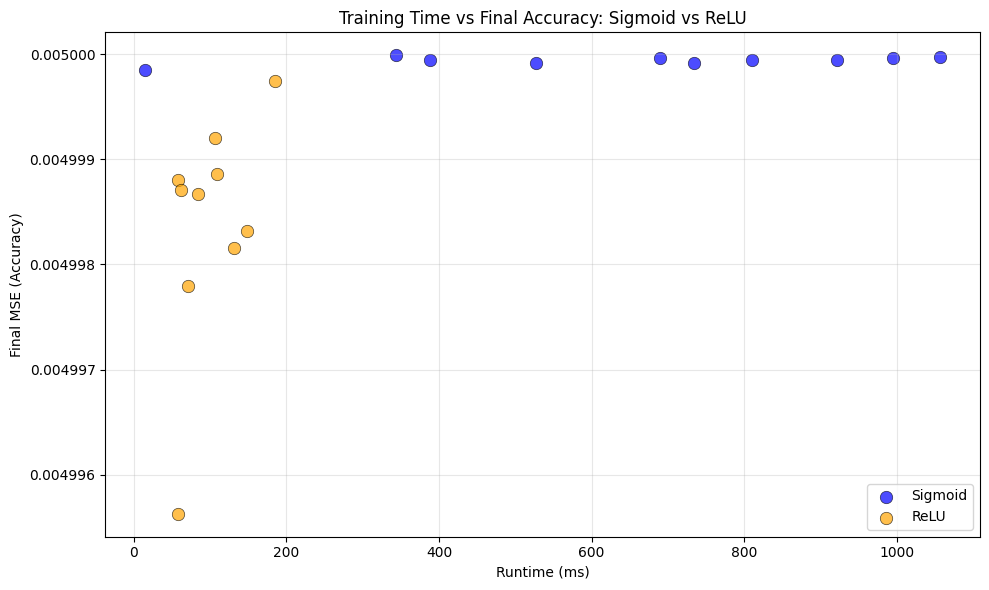

In [420]:
plotData(data)

#### Accuracy vs. Runtime - 0.001 Scalar and 0.001 Accuracy (MSE)
![](Attachments/Scatter%20-%200.001%20MSE%20(Variable%20Scalar).png)

The graphs you see, the recently generated and the prior generation, are examples of what it looks like when you train the two types of models (Sigmoid vs. ReLU) with with the same scalars, each aiming for 0.001 Accuracy (MSE). Notably, when you allow for the same scalar, the time difference starts to show. Building on prior information about low vs. high scalar, the tradeoffs here become very apparent as lower scalars are more efficient with ReLU than Sigmoid functions.